### [IDEA]

- 본 내용은 법률 자문이 아닌 법령 정보 안내이며, 구체적인 법적 판단은 전문가와 상담하시기 바랍니다.
    - 이거는 챗봇 하단 ui에 들어가면 좋겠다.

### 0. 라이브러리 모음 및 State 설정

##### State 필드 모음
| 필드 | 역할 | 설정 노드 |
|------|------|----------|
| `messages` | 대화 히스토리 누적 (add_messages 리듀서) | 전체 |
| `user_input` | 현재 사용자 입력 원문 | 초기값 |
| `intent_metadata` | RAG 검색 필터 | moderator2 |
| `retrieved_docs` | 검색된 문서 목록 | retrieval |
| `similarity_score` | 검색 최고 유사도 | retrieval |
| `is_sensitive` | 민감정보 포함 여부 | moderator1 |
| `is_definitive` | 확답 요구 질문 여부 | moderator2 |
| `needs_link` | 링크 요청 여부 (Tavily 트리거) | moderator2 |
| `final_answer` | 생성 → 정제 → 필터 거친 최종 답변 | generator~moderator3 |

In [1]:
# !pip install langgraph langchain langchain-core langchain-tavily

In [2]:
# !pip install langchain-openai

In [1]:
import sys
sys.path.insert(0, "..")

from dotenv import load_dotenv
load_dotenv()

import re
import json
from typing import TypedDict, Annotated, List, Optional

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from src.graph.state import State

c:\Users\jinsa\anaconda3\envs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
### 1. State 설정

# class State(TypedDict):
#     messages: Annotated[List, add_messages]  # add_messages: 덮어쓰기 대신 누적(append)
#     user_input: str
#     intent_metadata: Optional[dict]
#     retrieved_docs: Optional[List[dict]]    # node 3~4
#     similarity_score: Optional[float]
#     retrieval_passed: bool
#     fallback_message: str
#     is_terminated: bool                     # node 3~4
#     is_sensitive: bool                      # node 1
#     is_definitive: bool                     # node 2
#     needs_link: bool                        # node 2
#     final_answer: Optional[str]

###################################

# 2.State 초기값 설정(Graph 생성 후 진행!!) >>> 굳이기 싶긴 하다.

# graph.invoke({
#     "messages": [],
#     "user_input": "전세 보증금 관련 질문이요",
#     "intent_metadata": None,
#     "retrieved_docs": None,
#     "similarity_score": None,
#     "is_sensitive": False,
#     "is_definitive": False,
#     "needs_link": False,
#     "final_answer": None,
# })

In [5]:
# LLM 초기화 — 'provider:model' 형식으로 다양한 모델을 통일된 인터페이스로 사용
llm = init_chat_model('openai:gpt-4.1-mini')

# Tavily 검색 도구 — PDF 5번: 링크 요청 시에만 사용
tavily_tool = TavilySearch(max_results=3)

# Tool이 바인딩된 LLM — tool_calls 응답을 낼 수 있는 버전
llm_with_tools = llm.bind_tools([tavily_tool])

---

### 1. moderator 1

- 답변토록 하려면: 민감한 정보가 포함되어있지 않나요? 다시 한 번 확인해주세요!

In [6]:
### 0. 패턴 설정

SENSITIVE_PATTERNS = [
    (r'(?<!\d)\d{6}[\s-]?[1-4]\d{6}(?!\d)', "주민등록번호"),
    (r'(?<!\d)\d{6}[\s-]?[5-8]\d{6}(?!\d)', "외국인등록번호"),
    (r'(?<!\d)\d{3}[\s-]?\d{2}[\s-]?\d{5}(?!\d)', "사업자등록번호"),   
    (r'(?<!\d)\d{4}[\s-]?\d{4}[\s-]?\d{4}[\s-]?\d{4}\b(?!\d)', "카드번호"),
    (r'(?<!\d)\d{3,6}[-\s]?\d{2,6}[-\s]?\d{5,8}(?!\d)', "계좌번호"),                # 계좌번호 범위가 넓어서 오탐의 위험은 존재.
    (r'(?<!\d)(010|011|016|017|018|019)[-\s]?\d{3,4}[-\s]?\d{4}(?!\d)', "전화번호")

    ### 유의사항
    # '-'가 없는 주민등록번호/외국인등록번호와 계좌번호는 상황이 겹칠 수도 있다.
    # 그래서 경고문구를 출력할 때, 중복 태깅하도록 코드를 짤 예정
]

### 1. 함수 설정: 민감정보 유무를 확인 및 State update해주는 함수
# def detecting_private_sensitive_data(state: State) -> dict: # 원래 사용하려던 함수명
def check_sensitive_info(state: State) -> dict:
    '''
    <소개>
    개인정보 혹은 민감한 정보를 찾아내는 moderator1의 노드 함수입니다.

    <args>
    - State

    <output>
    - State의 요소를 다음과 같이 업데이트합니다.
        - 'is_sensitive' : 민감한 정보가 있으면 True, 없으면 False로 업데이트
        - 'messages' : 민감한 정보가 있는 경우, 어떤 류의 민감정보가 포함되어 있는지를 출력하고, 이를 포함하지 않도록 안내하는 str을 저장
    '''

    user_input = state['user_input']    # 이 함수나 이 바깥에서 State['user_input']를 input값으로 업데이트 하는 코드가 필요함...
    detected = []

    for pattern, label in SENSITIVE_PATTERNS:
        if re.search(pattern, user_input):
            detected.append(label)

    if detected:
        types_str = ", ".join(detected)
        warning_msg = (
            "<<주의>>\n"
            f"{types_str}로 보이는 정보가 포함되어 있습니다.\n"
            "민감한 정보가 포함되어있지 않나요? 다시 한 번 확인해주세요!\n\n"
            "예) 주민등록번호, 계좌번호와 같은 개인정보/민감정보는 보안상 입력하지 않도록 권장합니다."
        )

        return {
                'is_sensitive': True,
                'fallback_message': warning_msg 
            }   # detected 된 경우 return값 설정

    return {'is_sensitive': False}  # detected 안 된 경우 == 정상 통과



### 2. moderator_1의 조건부 엣지 함수
def route_after_check_sensitive_info(state: State) -> str:
    '''
    <소개>
    moderator_1 노드의 조건부 엣지 함수
    
    <기능>
    - is_sensitive 값에 따라 다음 노드 결정
        - True : 민감정보를 포함하고 있음 -> 경고 메시지 출력 및 END 노드 이동 (fall back)
        - False : 민감정보를 포함하고 있지 않음 -> moderator2로 이동
    '''

    if state['is_sensitive']:
        print(state['fallback_message'])

    return END if state['is_sensitive'] else 'intent_understanding'
    # State의 is_sensitive는 moderator1을 거치면 무조건 업데이트되므로 .get 메서드를 꼭 사용할 이유는 없다.
    # 그럼 END에 갔을 때 모두 공통적으로 그 message를 출력하게 하는 함수가 필요하곘네.

    # 원래 아래의 코드를 사용했으나, 위의 moderate1을 이렇게 사용한다면, 로직이 꼬여서 사용하지 않음
    # return END if state.get('is_sensitive', False) else 'moderator2_intent'

---

### 2. moderator 2

In [ ]:
MODERATOR_2_SYSTEM_PROMPT = """
사용자의 질문을 분석해서 아래 JSON만 반환하세요. 설명 없이.

분석 항목:
1. intent_metadata: 벡터 DB 검색에 사용할 필터
   - doc_type: 질문에 대한 답변 래퍼런스 카테고리 (다음 중 선택: "법령", "법령해석례", "판례")            >>> 이거는 판례/법령/해석례 등으로 category를 보도록 하는 게 나을 거 같은데..?
   - source: 참고할 출처 (파악 가능할 때만)
2. is_definitive: 확답을 요구하는 질문인지 여부
   - True 예시: "~이 맞나요?", "반드시 ~해야 하나요?", "~가 100% 맞죠?" "답변에 대해 책임을 질 수 있어요?", # fewshot prompting
   - False 예시: "~에 대해 알려주세요", "~는 어떻게 하나요?"
3. needs_link: 사용자가 링크/출처/참고자료를 요청했는지 여부

응답 형식 (JSON만):
{
  "intent_metadata": {"doc_type": "법령"},
  "is_definitive": False,
  "needs_link": False
}
"""

_FALLBACK_MSG_M2 = (
    "해당 질문은 명확한 확답을 드리기 어렵습니다.\n"
    "상황과 조건에 따라 답변이 달라질 수 있어요.\n"
    "더 구체적인 상황을 설명해주시면 더 도움이 될 수 있습니다."
)

def intent_understanding(state: State) -> dict:
    '''
    <소개>
    LLM으로 사용자의 질문 의도 및 확답을 요구하는 질문을 차단하기 위한 moderator2 노드의 함수입니다.
    (1) 확답 질문 차단
    (2) 메타데이터 추출
    
    <args>
    - State

    <output>
    - State의 요소를 다음과 같이 업데이트합니다.
        - 'is_definitive' : 확답을 요구하는 경우가 존재한다면 
        'messages' : 민감한 정보가 있는 경우, 어떤 류의 민감정보가 포함되어 있는지를 출력하고, 이를 포함하지 않도록 안내하는 str을 저장
    '''
    
    user_input = state['user_input']

    response = llm.invoke([
        SystemMessage(content=MODERATOR_2_SYSTEM_PROMPT),
        HumanMessage(content=user_input)
    ])

    # LLM이 코드블록으로 감쌀 경우를 대비한 전처리
    raw = response.content.strip().strip('```json').strip('```').strip()
    
    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        # 파싱 실패 시 안전한 기본값 사용
        result = {"intent_metadata": {'doc_type' : None}, "is_definitive": False, "needs_link": False}

    # PDF 2-C: 확답 질문 → Fallback END
    if result.get('is_definitive', False):  # >>> 이 조건문 변경해야할 수도 있음... (캥기는 부분이 있는데..) >>> result['is_definitive']로 하면되는..?
        return {
            'is_definitive': True,
            'fallback_message': _FALLBACK_MSG_M2
        }

    return {
        'is_definitive': False,
        'intent_metadata': result.get('intent_metadata', {}),  # PDF 2-B: Retrieval 메타데이터
        'needs_link': result.get('needs_link', False)
    }

### 2. 조건부 엣지 함수
def route_after_intent_understanding(state: State) -> str:
    '''
    <소개>
    moderator_2 노드의 조건부 엣지 함수
    
    <기능>
    - is_definitive 값에 따라 다음 노드 결정
        - True : 확답을 요구하고 있음 -> 경고 메시지 출력 및 END 노드 이동 (fall back)
        - False : 확답을 요구하고 있지 않음 -> retrieval로 이동
    '''

    if state['is_definitive']:
        print(state['fallback_message'])

    return END if state['is_definitive'] else 'retrieve'

---

### 3. Retrieve

In [1]:
from functools import lru_cache
from typing import Any

from qdrant_client.models import FieldCondition, Filter, MatchValue

from src.config import COLLECTION_NAME, EMBEDDING_MODEL, RETRIEVAL_TOP_K
from src.graph.state import State
from src.vectordb import Embedder, QdrantStore


@lru_cache(maxsize=1)
def _get_store() -> QdrantStore:
  """QdrantStore 싱글턴 반환.

  임베더와 컬렉션을 한 번만 초기화
  """
  embedder = Embedder(EMBEDDING_MODEL)
  return QdrantStore(
    collection_name=COLLECTION_NAME,
    embedder=embedder,
  )


def _build_filter(
  intent_metadata: dict[str, str] | None,
) -> Filter | None:
  """
  intent_metadata에서 Qdrant payload 필터를 생성한다.

  Args:
    intent_metadata: 의도 분류에서 태깅된 메타데이터.
      doc_type 키가 있으면 해당 값으로 필터링한다.

  Returns:
    Filter 객체 또는 None (필터 조건 없음).
  """
  if not intent_metadata:
    return None

  conditions: list[FieldCondition] = []

  doc_type = intent_metadata.get("doc_type")
  if doc_type:
    conditions.append(
      FieldCondition(key="doc_type", match=MatchValue(value=doc_type))
    )

  if not conditions:
    return None

  return Filter(must=conditions)


def retrieve(state: State) -> State:
  """Qdrant에서 사용자 질의와 관련된 문서를 검색한다.

  Args:
    state: 파이프라인 상태. user_input과 intent_metadata 필요.

  Returns:
    retrieved_docs와 similarity_score 키가 갱신된 상태.
  """
  store = _get_store()
  query = state["user_input"]
  metadata = state.get("intent_metadata", {})

  filters = _build_filter(metadata)
  results: list[dict[str, Any]] = store.search(
    query=query,
    top_k=RETRIEVAL_TOP_K,
    filters=filters,
  )

  similarity_score = results[0]["score"] if results else 0.0

  return {
    "retrieved_docs": results,
    "similarity_score": similarity_score,     # 원본 코드에는 top_score라고 되어있었는데, 일단 similarity_score로 이름 변경
  }

ModuleNotFoundError: No module named 'src'

---

### 4. 유사도 확인 (변경 사항 생김 > git 파일 수정할 필요가 있다)

In [9]:
from src.config import RELEVANCE_THRESHOLD
# from src.graph.state import PipelineState

_FALLBACK_MSG_CR = (
  "죄송합니다, 해당 질문에 대한 정확한 답변을 찾지 못했습니다. "
  "질문을 좀 더 구체적으로 입력해주시겠어요?"
)


def check_relevance(
  state: State,
  threshold: float | None = None,
) -> State:
  """
  검색 결과의 유사도 점수를 기준으로 응답 가능 여부를 판정

  Args:
    state: 파이프라인 상태. retrieved_docs와 similarity_score 필요
    threshold: 유사도 임계값. None이면 config 기본값 사용

  Returns:
    retrieval_passed, fallback_message, is_terminated 키가 갱신된 상태
  """
  threshold = threshold if threshold is not None else RELEVANCE_THRESHOLD
  docs = state.get("retrieved_docs", [])
  similarity_score = state.get("similarity_score", 0.0)

  passed = len(docs) > 0 and similarity_score >= threshold

  if passed:
    return {
      "retrieval_passed": True,   # ↓ 자매품으로 이 친구도 알아보면 좋을 것 같다.
      "fallback_message": None,
      "is_terminated": False,     # 얘는 무슨 의도인지 확인해야할 것 같다.
    }

  return {
    "retrieval_passed": False,
    "fallback_message": _FALLBACK_MSG_CR,
    "is_terminated": True,
  }

def route_after_check_relevance(state: State) -> str:
    '''
    <소개>
    check_relevance 노드의 조건부 엣지 함수
    
    <기능>
    - retrieval_passed 값에 따라 다음 노드 결정
        - True : 통과(다음 단계로)
        - False : Fallback(-> END)
    '''
    
    if state['retrieval_passed'] == False:
      print(state['fallback_message'])

    return 'generator' if state['retrieval_passed'] else END

---

### 5. Generator >>> 맥락을 줘야함

In [10]:
GENERATOR_SYSTEM_PROMPT = """\
당신은 사용자의 질문에 대해 주어진 context에 기반해 답변하는 부동산 전문가입니다.
사용자가 링크를 요청하면 'tavily' 도구를 호출하여 URL을 확보한 뒤 답변에 포함하세요.

[역할(Role)]
- 주택임대차보호법, 판례, 법령해석례를 기반으로 사용자가 계약 관련 궁금증을 해소할 수 있도록 정확한 정보를 안내합니다.
- 복잡한 법률 용어를 일반인도 이해할 수 있도록 쉽게 설명합니다.
- 제공된 법령/판례/해석례 문서만을 근거로 답변합니다.

[제약조건(Constraints)]
- 제공된 참고 문서를 기반으로 답변하세요.
- 문서에 없는 내용은 추측하거나 지어내지 마세요.
- 모든 답변에 반드시 출처(법령명, 조문번호, 판례번호)를 명시하세요.
- 확답 표현(반드시, 무조건, 절대적으로, 100% 등)은 사용하지 마세요.
- 법률적 판단이나 개인 법률 자문은 제공하지 않습니다.
- 간결하고 명확하게 답변하세요."""


def generator(state: State) -> dict:
    """PDF 5번: 검색 문서 기반 답변 생성 + needs_link일 때만 Tavily Tool 사용"""
    user_input     = state['user_input']
    retrieved_docs = state.get('retrieved_docs', [])
    needs_link     = state.get('needs_link', False)

    # 검색된 문서를 컨텍스트로 조합
    context = "\n\n".join(
        f"[출처: {doc['metadata'].get('source', '알 수 없음')}]\n{doc['content']}"
        for doc in retrieved_docs
    )

    messages = [
        SystemMessage(content=GENERATOR_SYSTEM_PROMPT),
        HumanMessage(content=f"참고 문서:\n{context}\n\n질문: {user_input}")
    ]

    # generator 내장된 Tavily tool이라서 이렇게 되면 독립된 Tavily tool 노드는 없게 되는 듯 합니다...
    if needs_link:
        # PDF 5번 Tool: 링크 요청 시에만 Tavily 실행
        ai_response = llm_with_tools.invoke(messages)

        if hasattr(ai_response, 'tool_calls') and ai_response.tool_calls:
            tool_call   = ai_response.tool_calls[0]
            tool_result = tavily_tool.invoke(tool_call['args'])

            # 툴 결과를 대화에 추가 후 최종 응답 생성
            messages.append(ai_response)
            messages.append(ToolMessage(
                content=str(tool_result),
                tool_call_id=tool_call['id']
            ))
            final_response = llm.invoke(messages)
        else:
            final_response = ai_response
    else:
        # 링크 불필요 → 일반 LLM 호출 (비용 절감)
        final_response = llm.invoke(messages)

    return {
        'final_answer': final_response.content,
        'messages': [final_response]
    }

---

### 6. Formatter

In [11]:
FORMATTER_SYSTEM_PROMPT = """\
당신은 Generation에 대해 답변의 스타일을 정제해 주는 AI 어시스턴트입니다.

규칙:
1. 불필요한 서두("물론입니다", "좋은 질문입니다" 등) 제거
2. 핵심 내용 위주로 구조화 (필요 시 번호 목록 사용)
3. 문장은 간결하게 (한 문장에 하나의 내용만)
4. 마크다운 형식 유지

==================

[출력 형식 (Format)]

답변: (핵심 내용을 쉬운 말로 설명하되 확답의 표현은 자제)

관련 법령/판례:
  - [출처] [법령명 또는 판례번호] : (법령/판례의 핵심 내용)
"""

def formatter(state: State) -> dict:
    """PDF 6번: generator 출력을 사용자에게 노출하기 좋은 형태로 정제"""
    final_answer = state.get('final_answer', '')
    if not final_answer:
        return {}

    response = llm.invoke([
        SystemMessage(content=FORMATTER_SYSTEM_PROMPT),
        HumanMessage(content=final_answer)
    ])

    return {
        'final_answer': response.content,
        'messages': [AIMessage(content=response.content)]
    }

---

### 7. Moderator 3

In [12]:
# 1차 정규식 감지 패턴
DEFINITIVE_PATTERNS = [
    r'반드시',
    r'무조건',
    r'절대적으로',
    r'확실히',
    r'틀림없이',
    r'100\s*%',
    r'무조건적',
]

MODERATOR_3_SYSTEM_PROMPT = """\
아래 텍스트에서 확답을 주는 단정적 표현을 부드러운 표현으로 교체하세요.

교체 기준:
- "반드시" → "일반적으로"
- "무조건" → "대부분의 경우"
- "절대적으로" → "대체로"
- "확실히" → "일반적으로 보면"
- "틀림없이" → "보통은"
- "100%" → "대부분"

내용과 맥락은 유지하고, 단정적 표현만 교체하세요.
수정된 텍스트만 반환하세요."""


def expression_revision(state: State) -> dict:
    """PDF 7번: 정규식 1차 감지 → 확답 표현 있을 때만 LLM으로 교체"""
    final_answer = state.get('final_answer', '')
    if not final_answer:
        return {}

    # 1차: 정규식 — 확답 표현 없으면 LLM 호출 생략 (비용 절감)
    has_definitive = any(re.search(p, final_answer) for p in DEFINITIVE_PATTERNS)

    if not has_definitive:
        return {'messages': [AIMessage(content=final_answer)]}

    # 2차: LLM — 문맥을 유지하며 자연스럽게 표현 교체
    response = llm.invoke([
        SystemMessage(content=MODERATOR_3_SYSTEM_PROMPT),
        HumanMessage(content=final_answer)
    ])

    return {
        'final_answer': response.content,
        'messages': [AIMessage(content=response.content)]
    }

---

### <통합> Langgraph Outline 구축

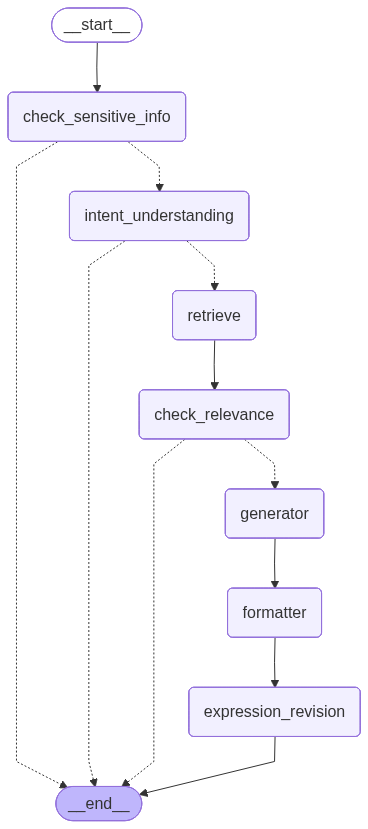

In [13]:
builder = StateGraph(State)

### 노드 추가
builder.add_node('check_sensitive_info', check_sensitive_info)
builder.add_node('intent_understanding', intent_understanding)
builder.add_node('retrieve', retrieve)
builder.add_node('check_relevance', check_relevance)
# builder.add_node('follow_up', follow_up) > 꼬리질문 노드가 있으면 더 좋을 듯
builder.add_node('generator', generator)
builder.add_node('formatter', formatter)
builder.add_node('expression_revision', expression_revision)

### 엣지 추가
builder.add_edge(START, 'check_sensitive_info')
builder.add_conditional_edges(
    'check_sensitive_info', route_after_check_sensitive_info,
    {END: END, 'intent_understanding': 'intent_understanding'}
    )
builder.add_conditional_edges(
    'intent_understanding', route_after_intent_understanding,
    {END: END, 'retrieve': 'retrieve'}
)
builder.add_edge('retrieve', 'check_relevance')
builder.add_conditional_edges(
    'check_relevance', route_after_check_relevance,
    {END: END, 'generator':'generator'}
)
builder.add_edge('generator', 'formatter')
builder.add_edge('formatter','expression_revision')
builder.add_edge('expression_revision', END)

# graph 형성
graph = builder.compile()
graph

---

### 테스팅

In [14]:
def run(user_input: str) -> str:
    """그래프를 실행하고 마지막 AI 응답 텍스트를 반환"""
    initial_state: State = {
        'messages':         [HumanMessage(content=user_input)],
        'user_input':       user_input,
        'metadata_filter':  None,
        'retrieved_docs':   None,
        'similarity_score': None,
        'is_sensitive':     False,
        'is_definitive':    False,
        'needs_link':       False,
        'final_answer':     None,
    }
    result = graph.invoke(initial_state)
    return result['messages'][-1].content

In [15]:
# 테스트 1: 정상 질문 → 전체 파이프라인 통과
# 예상 경로: moderator1 → moderator2 → retrieval → similarity_check → generator → formatter → moderator3
print("=== 테스트 1: 일반 질문 ===")
print(run("LangGraph에 대해 알려주세요."))

=== 테스트 1: 일반 질문 ===


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 5481.89it/s]


죄송합니다, 해당 질문에 대한 정확한 답변을 찾지 못했습니다. 질문을 좀 더 구체적으로 입력해주시겠어요?
LangGraph에 대해 알려주세요.


In [16]:
# 테스트 2: 민감정보 포함 → moderator1에서 차단
# 예상 경로: moderator1 → END (경고 메시지)
print("=== 테스트 2: 민감정보 포함 ===")
print(run("내 주민번호는 900101-1234567이에요."))

=== 테스트 2: 민감정보 포함 ===
<<주의>>
주민등록번호, 계좌번호로 보이는 정보가 포함되어 있습니다.
민감한 정보가 포함되어있지 않나요? 다시 한 번 확인해주세요!

예) 주민등록번호, 계좌번호와 같은 개인정보/민감정보는 보안상 입력하지 않도록 권장합니다.
내 주민번호는 900101-1234567이에요.


In [17]:
# 테스트 3: 확답 요구 질문 → moderator2에서 차단
# 예상 경로: moderator1 → moderator2 → END (확답 불가 안내)
print("=== 테스트 3: 확답 질문 ===")
print(run("이 방법이 100% 맞는 방법인가요?"))

# 확답을 요구했는데 못 걸러냈다 이게 좀 심한 문제...

=== 테스트 3: 확답 질문 ===
해당 질문은 명확한 확답을 드리기 어렵습니다.
상황과 조건에 따라 답변이 달라질 수 있어요.
더 구체적인 상황을 설명해주시면 더 도움이 될 수 있습니다.
이 방법이 100% 맞는 방법인가요?


In [18]:
# 테스트 4: 링크 요청 → generator에서 Tavily Tool 사용
# 예상 경로: 전체 파이프라인 + Tavily API 호출
print("=== 테스트 4: 링크 요청 ===")
print(run("임대차 관련 정보가 필요해요. 관련 참고 링크도 같이 알려주세요."))    # 유저 쿼리를 왜 전처리 해야하는가를 여기서 확인할 수 있다...

=== 테스트 4: 링크 요청 ===
죄송합니다, 해당 질문에 대한 정확한 답변을 찾지 못했습니다. 질문을 좀 더 구체적으로 입력해주시겠어요?
임대차 관련 정보가 필요해요. 관련 참고 링크도 같이 알려주세요.


In [19]:
# 테스트 5
print("=== 테스트 5: 링크 요청 ===")
print(run("조기 계약 해지"))

=== 테스트 5: 링크 요청 ===
죄송합니다, 해당 질문에 대한 정확한 답변을 찾지 못했습니다. 질문을 좀 더 구체적으로 입력해주시겠어요?
조기 계약 해지
